In [1]:
import sys
import math
import numpy as np
import scipy
import matplotlib.pyplot as plt

sys.path.append('..')
from src.kernels import exp_kernel, complex_exp_kernel, complex_discrete_kernel
from src.probability import Distribution
from src.spectral_transforms import psi_real_to_circle, psi_inv_circle_to_real, B_real, B_circle
from src.numerical import solve_volterra_integrodiff, trap_quad, conv_trap
from src.plotting import plot_real_distribution, plot_discrete

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=8)
plt.rcParams.update({
    'font.size': 8,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsfonts}" + "\n" + r"\usepackage{amsmath}" + "\n" + r"\usepackage{amssymb}"
})

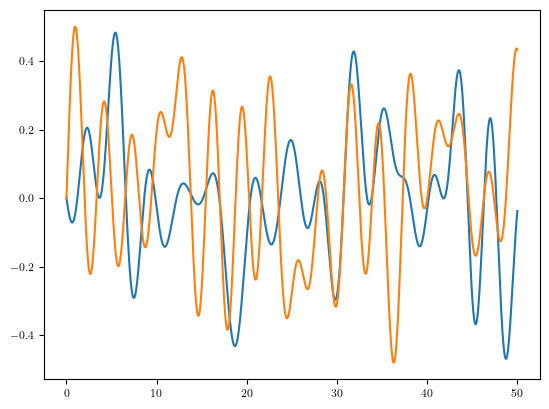

In [223]:
n = 9
psi_init = 1/np.sqrt(2) * (np.random.randn(n) + 1j*np.random.randn(n))
psi_init = np.insert(psi_init, 0, 0)
rho = np.sum(np.abs(psi_init)**2)
psi_init /= np.sqrt(rho)
# state e is at position 0

v = np.ones(n)
H_hat = np.diag(v, -1) + np.diag(v, 1)
H_hat[1, -1] = 1
H_hat[-1, 1] = 1

t = np.linspace(0, 50, int(1e5))
dt = t[1] - t[0]

A = scipy.linalg.expm(-1j*dt*H_hat)

psi = np.zeros((n+1, len(t)), dtype=np.complex128)
psi[:, 0] = psi_init
for i in range(len(t)-1):
    psi[:, i+1] = A @ psi[:, i]

phi0_true = psi[0, :]

plt.plot(t, np.real(phi0_true))
plt.plot(t, np.imag(phi0_true))
plt.show()

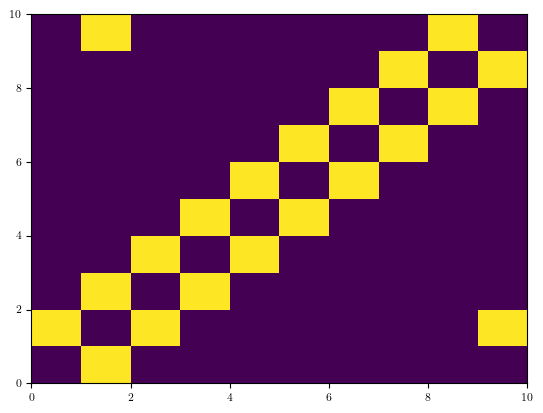

In [224]:
plt.pcolormesh(H_hat)
plt.show()

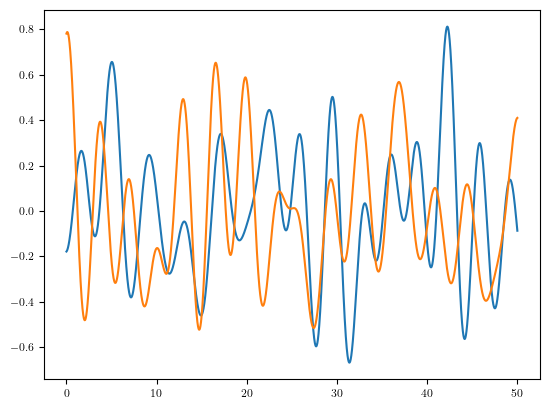

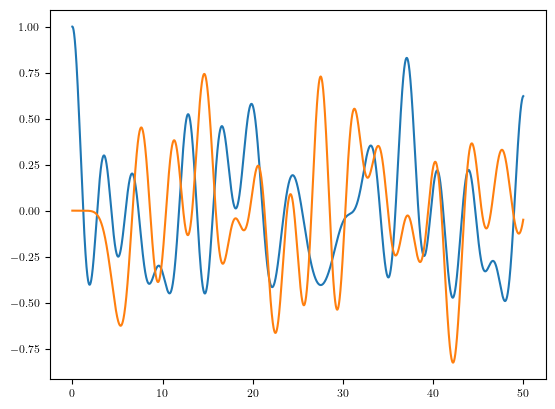

In [225]:
js = np.arange(n)
Ej = 1/np.sqrt(n)*np.exp(2j*np.pi*js[:, None]*js/n)
Nj = Ej.T.conj() @ psi_init[1:]
#rho = np.sum(np.abs(Nj)**2) + np.abs(psi_init[0])**2
f = 1/(1j*np.sqrt(n))*np.exp(-2j*np.cos(2*np.pi*js/n)*t[:, None]) @ Nj

K = 1/n*np.sum(np.exp(-2j*np.cos(2*np.pi*js/n)*t[:, None]), axis=1)

plt.plot(t, np.real(f))
plt.plot(t, np.imag(f))

plt.show()

plt.plot(t, np.real(K))
plt.plot(t, np.imag(K))
plt.show()

In [226]:
c0 = 0
c1 = 1
phi0_init = psi_init[0]
#phi0_numerical = solve_volterra_integrodiff(K, c0, c1, f, phi0_init, t)

In [227]:
# Define analytical spectral distribution lambda
density = None
atoms = np.sort(2*np.cos(2*np.pi*js/n))
atom_wts = 1/n*np.ones(n)
quad_pts, quad_wts = trap_quad(-2, 2, int(1e3))
lmbda = Distribution(density, atoms, atom_wts, quad_pts, quad_wts)

mu, zeta0, zeta1 = B_real(lmbda, c0, c1)
J = complex_exp_kernel(mu, t)

left and right roots found


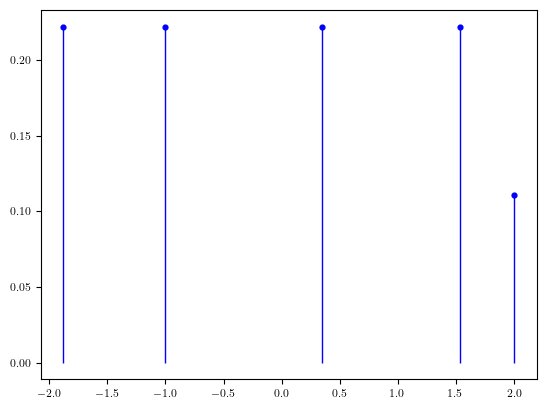

In [228]:
fig, ax = plt.subplots(1)
plot_real_distribution(ax, lmbda)

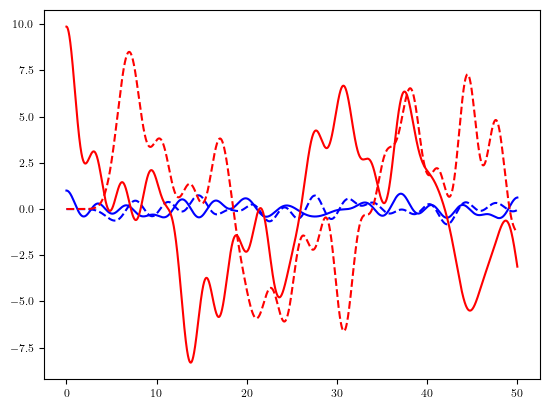

In [229]:
plt.plot(t, np.real(K), color="blue")
plt.plot(t, np.imag(K), color="blue", linestyle="--")
plt.plot(t, np.real(J), color="red")
plt.plot(t, np.imag(J), color="red", linestyle="--")
plt.show()

phi0_spectral = (1/math.pi**2) * (conv_trap(J, f - phi0_init*np.cumsum(K)*dt, t) + J[0]*phi0_init)

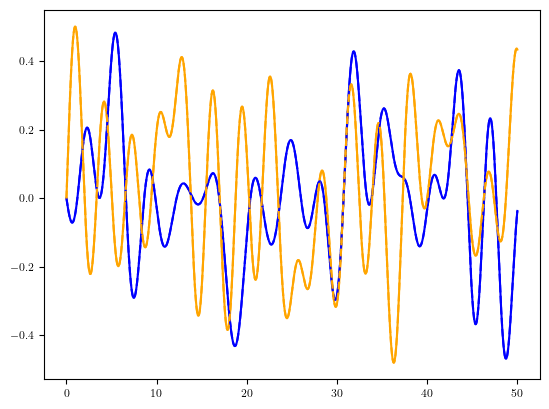

Spectral error:  4.791447412107264e-08


In [230]:
plt.plot(t, np.real(phi0_true), color="blue")
plt.plot(t, np.imag(phi0_true), color="orange")
#plt.plot(t, np.real(phi0_numerical), linestyle='--', color="blue")
#plt.plot(t, np.imag(phi0_numerical), linestyle='--', color="orange")
plt.plot(t, np.real(phi0_spectral), linestyle='--', color="blue")
plt.plot(t, np.imag(phi0_spectral), linestyle='--', color="orange")
plt.show()

#print("Numerical error: ", np.linalg.norm(phi0_true - phi0_numerical) / np.linalg.norm(phi0_true))
print("Spectral error: ", np.linalg.norm(phi0_true - phi0_spectral) / np.linalg.norm(phi0_true))


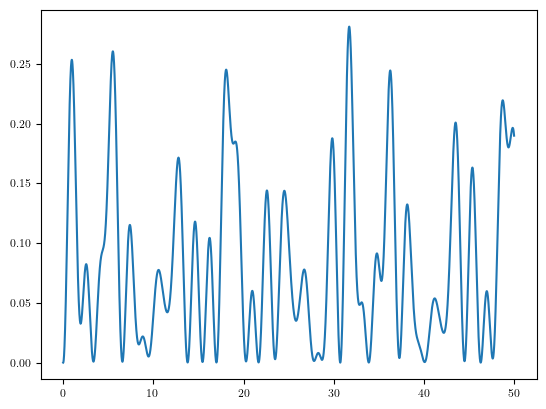

In [231]:
plt.plot(t, np.abs(phi0_true)**2)
plt.show()

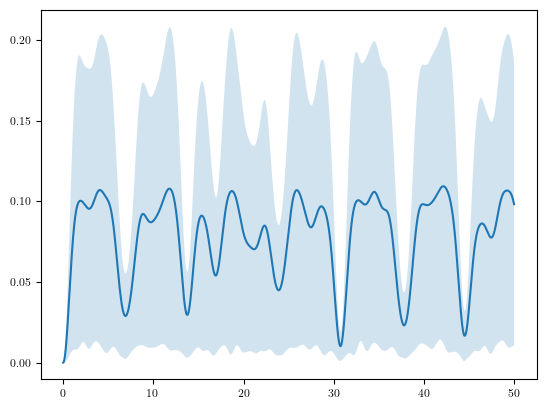

In [232]:
np.random.seed(1)

trials = 1000
ps = np.zeros((len(t), trials))
for i in range(trials):
    psi_init = 1/np.sqrt(2) * (np.random.randn(n) + 1j*np.random.randn(n))
    psi_init = np.insert(psi_init, 0, 0)
    rho = np.sum(np.abs(psi_init)**2)
    psi_init /= np.sqrt(rho)

    phi0_init = psi_init[0]
    Nj = psi_init[1:]
    f = 1/(1j*np.sqrt(n))*np.exp(-2j*np.cos(2*np.pi*js/n)*t[:, None]) @ Nj

    phi0 = (1/math.pi**2) * (conv_trap(J, f - phi0_init*np.cumsum(K)*dt, t) + J[0]*phi0_init)
    ps[:, i] = np.abs(phi0)**2

std = np.std(ps, axis=1)
plt.plot(t, np.mean(ps, axis=1))
plt.fill_between(t, np.mean(ps, axis=1) - std, np.mean(ps, axis=1) + std, alpha=0.2)
plt.show()

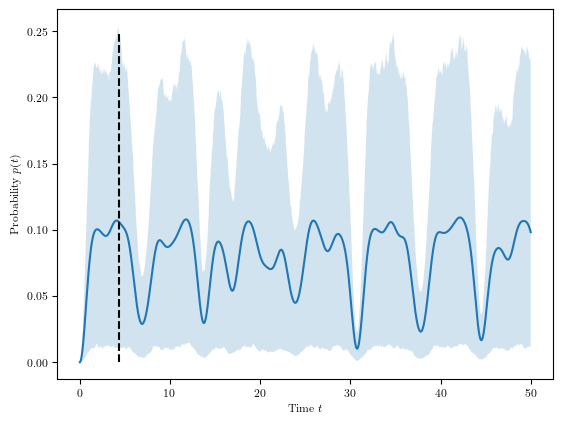

In [ ]:
p_mean = np.mean(ps, axis=1)
plt.plot(t, p_mean)
up = np.quantile(ps, 0.9, axis=1)
lp = np.quantile(ps, 0.1, axis=1)
#plt.fill_between(t, np.mean(ps, axis=1) - std, np.mean(ps, axis=1) + 10*std, alpha=0.2)
#plt.fill_between(t, np.max(ps, axis=1), np.min(ps, axis=1), alpha=0.2)
plt.fill_between(t, up, lp, alpha=0.2)
tmax = t[np.argmax(up)]
plt.vlines(tmax, ymin=0, ymax=0.25, linestyle="--", color="k")
plt.xlabel(f"Time $t$", fontsize=12)
plt.ylabel(f"Probability $p(t)$", fontsize=12)
plt.savefig(f"../figures/quantum_walk.pdf", bbox_inches='tight')
plt.show()